# **17 · 단일문항 신뢰 궤적 — 잠재모형 없이도 같은 이야기를 하는가 (삼각검증 B궤적의 해부)**

### **"뉴스 전반 신뢰(단일문항, 2020~2025)는 3.297→3.436으로 종점 최고·MK 부호 양(+) — 정렬 잠재추세(A궤적)와 방향이 일치하지만 저점 연도는 2022 vs 2024로 어긋난다. 이 일치와 불일치가 각각 무엇을 보증하고 무엇을 금지하는지 확정한다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = `trust_news_overall` 단일문항 궤적(B궤적) · 방법 = **가중 추세 산출 + SSOT 상수 대조 + A궤적과의 정직한 대비**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **③ EDA·시각화(교차 궤적)** · CRISP-DM **P2** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 단일문항 궤적은 어떤 자격으로 삼각검증에 참여하는가 — 모형 의존이 없는 대신 무엇을 잃는가?
> **Q2.** B궤적의 수치는 SSOT 상수(`TRUST_SINGLE`)·원자료 재검증(`12`)과 일치하는가?
> **Q3.** A궤적(정렬 잠재)과 **어디서 일치하고 어디서 어긋나는가** — 그 불일치가 강제하는 보고 규율은?

## **이 노트북의 위상**

`23` §4가 단일문항을 정렬추세의 교차확인으로 *스치듯* 썼고 `30` §3이 삼각검증의 한 궤적으로 *요약*했다면, 17은 B궤적 자체를 해부한다. 단일문항의 강점은 **모형 무의존**(원척도 그대로 — `12`에서 공표치와 전 셀 일치로 재검증된 바로 그 수치)이고, 약점은 **단일 지표의 측정오차·2019 부재**다. 이 비대칭이 "일치 = 강한 수렴 증거 / 불일치 = 단년 비교 금지"라는 규율을 만든다.

- **로직 SSOT(thin import)**: `alignment.single_item_trend`(가중 추세) · `trend_apc.mann_kendall`(부호 검정) · `p5_evaluation.TRUST_SINGLE`(인용 상수).
- **관련**: `12` §2(원전 재검증) · `23` §4 · `29`(삼각검증 심층) · `30` §3.

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 단일문항의 자격 — **Decision Box ①** | — |
| 2 | [실행] B궤적 산출(2020~2025, wt_year_eq) + [시각화] | 궤적표·figure |
| 3 | [발견] A궤적과의 대비 — 일치·불일치 + [시각화] | z-겹침 figure |
| 4 | [입증] 검증 셀 — TRUST_SINGLE·MK 부호·구조 assert | PASS |
| 5 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import alignment as al
import trend_apc as T
import p5_evaluation as P

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(al.PARQUET)
assert len(panel) == 90996
print(f"패널 {len(panel):,}행 · 인용 상수 TRUST_SINGLE {len(P.TRUST_SINGLE)}개년(2020~2025) 로드")
print(f"ALIGN_ALPHA(A궤적 상수) {len(P.ALIGN_ALPHA)}개년 로드 — §3 대비용")

패널 90,996행 · 인용 상수 TRUST_SINGLE 6개년(2020~2025) 로드
ALIGN_ALPHA(A궤적 상수) 7개년 로드 — §3 대비용


## **1. [전제] 단일문항은 어떤 자격으로 삼각검증에 참여하는가**

### **Decision Box ① — 왜 단일문항을 별도 궤적으로 유지하는가**

**기준: 잠재모형(A)이 있는데 단일문항(B)을 왜 버리지 않는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 잠재추세(A)만 보고 | 정렬법 α̂만 사용 | ❌ A의 수치는 **모형 의존**(2019-SD 단위) — 모형 선택이 만든 인공물일 가능성을 스스로 반증할 수 없음 |
| (b) 단일문항(B)만 보고 | 원척도 평균만 사용 | ❌ 단일 지표는 측정오차 통제 불가 + 측정동등 검정 자체가 불가(지표 1개) + 2019 부재로 6개년 |
| (c) **병행(삼각검증)** | A·B·C(합성) 세 궤적의 방향 수렴을 증거로 | ✅ **채택** — B는 모형 무의존이라 A의 인공물 가설을 기각하는 **독립 증인**. 반대로 B의 측정오차는 A가 보완. 셋의 종점 방향 일치가 결론의 근거(30 §3) |

**B궤적의 특권**: 세 궤적 중 B만이 `12`(원자료 재검증)에서 **공식 보고서 공표치와 전 셀 일치**로 원전 검증됐다(2023~2025 평균·비율). 즉 B는 "KPF가 공표한 바로 그 숫자"의 연장선이다 — 모형이 개입할 자리가 없다.

## **2. [실행] B궤적 산출 — 2020~2025 가중 추세**

`single_item_trend()`가 `wt_year_eq` 가중으로 연도별 평균을 낸다(연도 내 상수배 성질에 의해 공식 가중 평균과 동일 — `13` §3 성질 3).

**[시각화] B궤적** — 점 주석은 인용 상수(`TRUST_SINGLE`)와 동일해야 하는 값. 음영 = 저점 연도(2022).

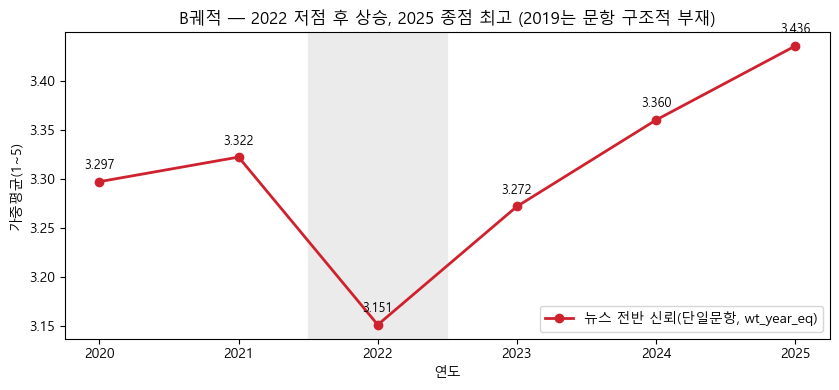

,year,mean,n,const,diff
0,2020,3.297185,5010,3.297,0.0002
1,2021,3.322248,5010,3.322,0.0002
2,2022,3.151102,58936,3.151,0.0001
3,2023,3.271849,5000,3.272,0.0002
4,2024,3.360109,6000,3.360,0.0001
5,2025,3.435645,6000,3.436,0.0004


In [2]:
bt = al.single_item_trend(panel)
bt["const"] = bt["year"].map(P.TRUST_SINGLE)
bt["diff"] = (bt["mean"] - bt["const"]).abs().round(4)

fig, ax = plt.subplots(figsize=(8.5, 4.0))
ax.axvspan(2021.5, 2022.5, color="0.92", zorder=0)
ax.plot(bt["year"], bt["mean"], "o-", lw=2, color="#cf222e", label="뉴스 전반 신뢰(단일문항, wt_year_eq)")
for _, r in bt.iterrows():
    ax.annotate(f"{r['mean']:.3f}", (r["year"], r["mean"]), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=9)
ax.set_xlabel("연도"); ax.set_ylabel("가중평균(1~5)")
ax.set_title("B궤적 — 2022 저점 후 상승, 2025 종점 최고 (2019는 문항 구조적 부재)")
ax.legend(loc="lower right"); ax.margins(x=0.05)
fig.tight_layout(); plt.show()
bt

**관찰**: 3.297(2020) → 3.322 → **3.151(2022 저점)** → 3.272 → 3.360 → **3.436(2025 최고)**. 상수 대조 열(`diff`)이 전부 0.001 이하 — 노트북 재실행이 인용 상수를 그대로 재생산한다. 원척도 기준 2023~2025 구간은 `12`에서 공표치(3.27/3.36/3.44)와도 일치가 확인된 값이다.

## **3. [발견] A궤적과의 대비 — 일치가 보증하는 것, 불일치가 금지하는 것**

**[시각화] A·B z-겹침** — 두 궤적을 각자 z-표준화해 겹친다(척도가 달라 수준 비교는 무의미, **형상**만 본다). 공통 구간(2020~2025) 기준: 종점(2025)이 두 궤적 모두 최고이고 방향(상승)이 일치하지만, **저점이 B=2022, A=2024로 어긋난다**.

C:\Users\kik32\AppData\Local\Temp\ipykernel_37300\3430416327.py:20: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Malgun Gothic.
  fig.tight_layout(); plt.show()
C:\Users\kik32\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


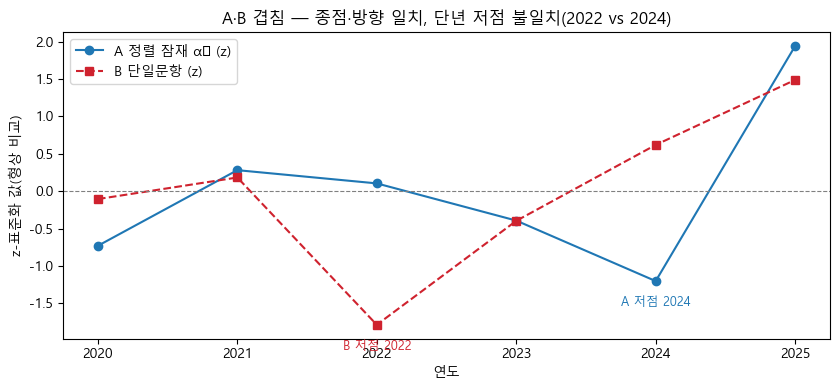

B궤적 MK: S=7 τ=+0.467 (부호 양) · A↔B Spearman ρ=+0.200
종점 최고 일치: A 2025 · B 2025


In [3]:
yrs_b = bt["year"].to_numpy()
b = bt["mean"].to_numpy()
a = np.array([P.ALIGN_ALPHA[int(y)] for y in yrs_b])   # A궤적(공통 구간 2020~2025)

def z(v):
    v = np.asarray(v, float)
    return (v - v.mean()) / v.std(ddof=0)

fig, ax = plt.subplots(figsize=(8.5, 4.0))
ax.plot(yrs_b, z(a), "o-", color="#1f77b4", label="A 정렬 잠재 α̂ (z)")
ax.plot(yrs_b, z(b), "s--", color="#cf222e", label="B 단일문항 (z)")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.annotate("B 저점 2022", (2022, z(b)[list(yrs_b).index(2022)]), textcoords="offset points",
            xytext=(0, -18), ha="center", fontsize=9, color="#cf222e")
ax.annotate("A 저점 2024", (2024, z(a)[list(yrs_b).index(2024)]), textcoords="offset points",
            xytext=(0, -18), ha="center", fontsize=9, color="#1f77b4")
ax.set_xlabel("연도"); ax.set_ylabel("z-표준화 값(형상 비교)")
ax.set_title("A·B 겹침 — 종점·방향 일치, 단년 저점 불일치(2022 vs 2024)")
ax.legend()
fig.tight_layout(); plt.show()

mk_b = T.mann_kendall(b)
from scipy.stats import spearmanr
rho = spearmanr(a, b).statistic
print(f"B궤적 MK: S={mk_b['S']} τ={mk_b['tau']:+.3f} (부호 양) · A↔B Spearman ρ={rho:+.3f}")
print(f"종점 최고 일치: A {max(P.ALIGN_ALPHA, key=P.ALIGN_ALPHA.get)} · B {int(bt.loc[bt['mean'].idxmax(), 'year'])}")

**관찰 — 이 대비가 만드는 규율 두 가지**:

1. **일치(종점 방향·2025 반등·MK 부호 양)** → "상승 방향"은 모형 의존이 아니다. 잠재모형을 걷어낸 원척도에서도 같은 방향이 나온다 — C3 삼각 일관성 관문(`30` §1)의 핵심 근거.
2. **불일치(저점 2022 vs 2024, Spearman 낮음)** → 연도 서열·단년 수준 비교는 궤적 간에 어긋난다. 그래서 **"몇 년이 최저였다" 류 단년 비교는 보고서에서 금지**(p6-pdf-structure §3.6) — 불일치를 숨기지 않고 규율의 근거로 전환한다(`30` DB②). B의 2022 저점은 표본 구성이 크게 바뀐 해(`16`)라는 점도 단년 해석을 더 조심하게 만든다.

## **4. [입증] 검증 셀**

In [4]:
# (a) B궤적 ↔ TRUST_SINGLE 상수 6개년 ±0.001
for _, r in bt.iterrows():
    assert abs(r["mean"] - P.TRUST_SINGLE[int(r["year"])]) <= 1e-3, f"{int(r['year'])} drift"
print("(a) B궤적 ↔ TRUST_SINGLE 6개년 ±0.001 전부 일치 PASS")

# (b) 구조 — 2019 부재, 2020~2025 6개년
assert list(bt["year"]) == [2020, 2021, 2022, 2023, 2024, 2025]
n2019 = int(panel.loc[panel["year"] == 2019, "trust_news_overall"].notna().sum())
assert n2019 == 0
print("(b) 2019 구조적 부재(유효 0) · B궤적 = 6개년 PASS")

# (c) 방향 — MK 부호 양 · 종점 최고 · 저점 2022
assert mk_b["S"] > 0
assert int(bt.loc[bt["mean"].idxmax(), "year"]) == 2025
assert int(bt.loc[bt["mean"].idxmin(), "year"]) == 2022
print(f"(c) MK S={mk_b['S']}>0 · 종점 2025 최고 · 저점 2022 PASS")

# (d) A와의 대비 — 공통 구간에서 A 저점은 2024(불일치의 실재)
a_common = {y: P.ALIGN_ALPHA[y] for y in range(2020, 2026)}
assert min(a_common, key=a_common.get) == 2024
print("(d) A궤적 저점 2024 ≠ B궤적 저점 2022 — '정직한 불일치' 실재 PASS")
print("\n검증 (a)~(d) 전부 PASS")

(a) B궤적 ↔ TRUST_SINGLE 6개년 ±0.001 전부 일치 PASS
(b) 2019 구조적 부재(유효 0) · B궤적 = 6개년 PASS
(c) MK S=7>0 · 종점 2025 최고 · 저점 2022 PASS
(d) A궤적 저점 2024 ≠ B궤적 저점 2022 — '정직한 불일치' 실재 PASS

검증 (a)~(d) 전부 PASS


## **5. 종합**

### **연구질문 답**

- **Q1** — B궤적은 모형 무의존·원전 재검증(`12`)이라는 자격으로 삼각검증에 참여한다. 대가는 단일 지표의 측정오차와 2019 부재(6개년) — 그래서 단독 결론이 아니라 **독립 증인**으로 쓴다(DB①).
- **Q2** — 6개년 전부 `TRUST_SINGLE`과 ±0.001 일치(§4 (a)), 2023~2025 구간은 공표치와도 일치(`12` 계승).
- **Q3** — 일치: 종점 2025 최고·상승 방향·MK 부호 양 → "상승 방향은 모형 인공물이 아니다". 불일치: 저점 2022 vs 2024 → **단년 수준 비교 금지 규율**의 실증 근거(§3).

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | B궤적 산출 + 상수 대조 [시각화] | 6개년 일치 |
| 3 | A·B z-겹침 — 일치·불일치 분리 | 규율 확정 |
| 4 | 일괄 assert | **PASS** |

**다음**: `18`(신뢰도·상관구조)이 배터리의 데이터 쪽 토대를, `29`(삼각검증 심층)가 C궤적까지 포함한 3연 대비를 완성한다.